<a href="https://colab.research.google.com/github/Mehul-Bansal1606/Student-Performance-Analysis/blob/main/Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (20, 5)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Study_Hours     20 non-null     int64
 1   Attendance      20 non-null     int64
 2   Previous_Score  20 non-null     int64
 3   Sleep_Hours     20 non-null     int64
 4   Exam_Score      20 non-null     int64
dtypes: int64(5)
memory usage: 932.0 bytes
None

Summary statistics:


,Study_Hours,Attendance,Previous_Score,Sleep_Hours,Exam_Score
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,4.800000,78.550000,68.000000,6.750000,70.250000
std,2.067289,11.869798,11.756297,0.966546,15.120133
min,1.000000,55.000000,45.000000,5.000000,42.000000
25%,3.000000,69.750000,59.500000,6.000000,57.500000
50%,5.000000,79.000000,69.000000,7.000000,71.500000
75%,6.250000,88.500000,76.500000,7.250000,81.000000
max,8.000000,96.000000,88.000000,8.000000,94.000000


Missing values:
Study_Hours       0
Attendance        0
Previous_Score    0
Sleep_Hours       0
Exam_Score        0
dtype: int64


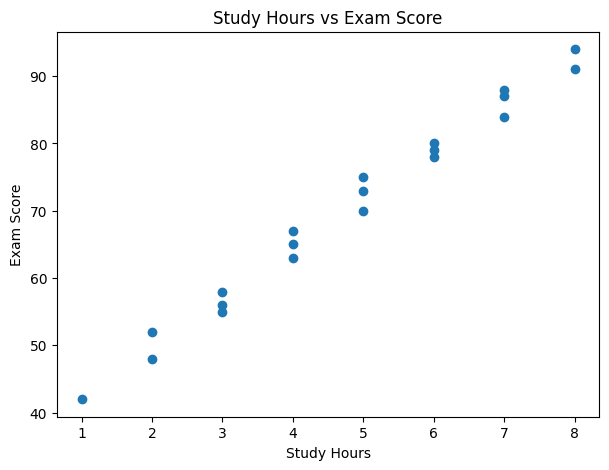

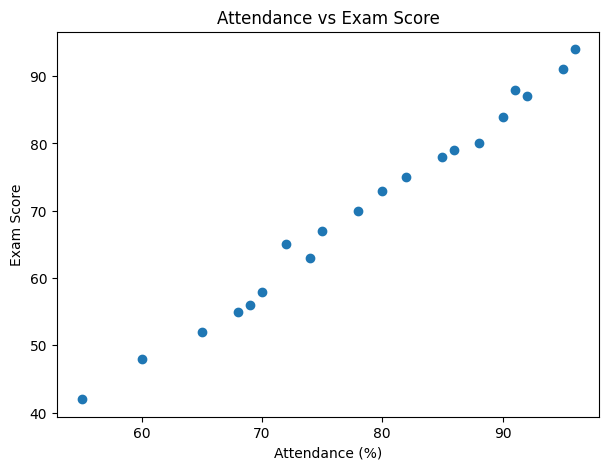

Exam_Score        1.000000
Attendance        0.995092
Previous_Score    0.994558
Study_Hours       0.993440
Sleep_Hours       0.872433
Name: Exam_Score, dtype: float64


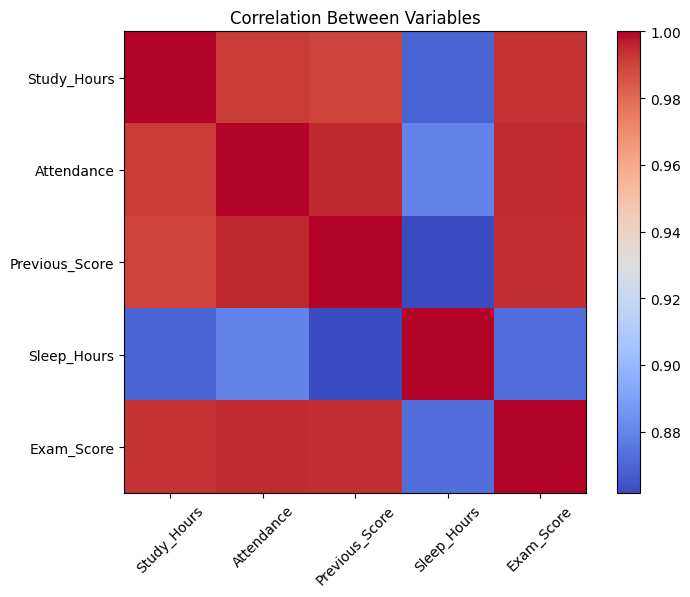

Mean Absolute Error: 1.7607904441004578
R² Score: 0.981689292196459


In [ ]:
# Student Performance Analysis

#A beginner-level data analysis project exploring the relationship
#between students' study habits, attendance, and academic performance.

## Tools Used
#- Python
#- Pandas
#- NumPy
#- Matplotlib
#- Scikit-learn




import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    "Study_Hours": [2, 3, 4, 5, 6, 7, 8, 2, 4, 6,
                    3, 5, 7, 8, 1, 4, 6, 7, 3, 5],

    "Attendance": [65, 70, 72, 78, 85, 90, 95, 60, 75, 88,
                   68, 80, 92, 96, 55, 74, 86, 91, 69, 82],

    "Previous_Score": [55, 60, 62, 68, 72, 78, 85, 50, 65, 76,
                       58, 70, 82, 88, 45, 64, 74, 80, 57, 71],

    "Sleep_Hours": [6, 6, 7, 7, 8, 7, 8, 5, 6, 8,
                    6, 7, 7, 8, 5, 6, 8, 7, 6, 7],

    "Exam_Score": [52, 58, 65, 70, 78, 84, 91, 48, 67, 80,
                   55, 73, 87, 94, 42, 63, 79, 88, 56, 75]
}

df = pd.DataFrame(data)

df.head()



print("Dataset shape:", df.shape)
print("\nDataset information:")
print(df.info())

print("\nSummary statistics:")
display(df.describe())


print("Missing values:")
print(df.isnull().sum())


plt.figure(figsize=(7,5))

plt.scatter(df["Study_Hours"], df["Exam_Score"])

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")

plt.show()




plt.figure(figsize=(7,5))

plt.scatter(df["Attendance"], df["Exam_Score"])

plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")

plt.show()


correlation = df.corr(numeric_only=True)

print(correlation["Exam_Score"].sort_values(ascending=False))


plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Between Variables")

plt.show()


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df[["Study_Hours", "Attendance", "Previous_Score", "Sleep_Hours"]]
y = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))
print("R² Score:", r2_score(y_test, predictions))